## Reducers, Annotated, Accumulation

#### 🔷 REDUCER — The Problem It Solves

Each parallel branch wrote to a DIFFERENT
key.

But what if two branches both write to the SAME key?

Without a reducer → the last writer WINS and data is lost.

With a reducer → values are MERGED (e.g., list appended).

```
Syntax:
- Annotated[list[str], operator.add]
    - type -> list[str]
    - operator.add -> metadata
    - reducer -> list concatenation
```


In [ ]:
from typing import TypedDict, Annotated
import operator


# --- 1. STATE ---
class State(TypedDict):
    input: str

    # WITHOUT reducer — each write OVERWRITES the previous value
    last_writer: str

    # WITH reducer — each write APPENDS to the list
    all_steps: Annotated[list[str], operator.add]

    # Plain int — also overwrites each time
    counter: int

In [18]:
# --- 2. NODES (sequential pipeline to show accumulation) ---
def step_a(state: State) -> dict:
    print("[step_a] Running...")
    return {
        "last_writer": "step_a",  # will be overwritten by step_b and step_c
        "all_steps": ["step_a executed"],  # APPENDED to list
        "counter": 1,
    }


def step_b(state: State) -> dict:
    print("[step_b] Running...")
    return {
        "last_writer": "step_b",
        "all_steps": ["step_b executed"],  # APPENDED — doesn't erase step_a's entry
        "counter": state["counter"] + 10,
    }


def step_c(state: State) -> dict:
    print("[step_c] Running...")
    return {
        "last_writer": "step_c",
        "all_steps": ["step_c executed"],
        "counter": state["counter"] + 100,
    }


def show_result(state: State) -> dict:
    print("\n📊 State at show_result node:")
    print(f"  last_writer : '{state['last_writer']}' ← only the LAST writer survives")
    print(f"  all_steps   : {state['all_steps']}  ← ALL writes preserved by reducer")
    print(f"  counter     : {state['counter']}")
    return {}

In [19]:
from langgraph.graph import StateGraph, START, END


# --- 3. GRAPH CONSTRUCTION ---
builder = StateGraph(State)
builder.add_node("step_a", step_a)
builder.add_node("step_b", step_b)
builder.add_node("step_c", step_c)
builder.add_node("show_result", show_result)

builder.add_edge(START, "step_a")
builder.add_edge("step_a", "step_b")
builder.add_edge("step_b", "step_c")
builder.add_edge("step_c", "show_result")
builder.add_edge("show_result", END)

graph = builder.compile()

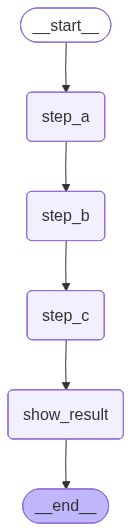

In [20]:
# --- 4. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
# --- 5. RUN & TEST ---
result = graph.invoke(
    {
        "input": "demo",
        "last_writer": "",
        "all_steps": [],  # starts empty; reducer appends to it
        "counter": 0,
    }
)
print("\n✅ Final state:")
print(f"  last_writer : {result['last_writer']}")
print(f"  all_steps   : {result['all_steps']}")
print(f"  counter     : {result['counter']}")

[step_a] Running...
[step_b] Running...
[step_c] Running...

📊 State at show_result node:
  last_writer : 'step_c' ← only the LAST writer survives
  all_steps   : ['step_a executed', 'step_b executed', 'step_c executed']  ← ALL writes preserved by reducer
  counter     : 111

✅ Final state:
  last_writer : step_c
  all_steps   : ['step_a executed', 'step_b executed', 'step_c executed']
  counter     : 111


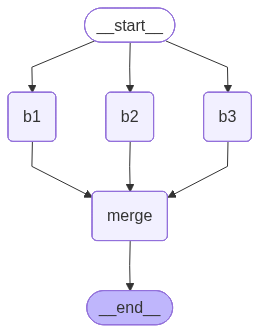


Report:
  • Branch 1: Found data about LangGraph
  • Branch 2: Found stats about LangGraph
  • Branch 3: Found news about LangGraph
✅ All 3 branch findings preserved because of Annotated reducer!


In [24]:
# ─────────────────────────────────────────────────────
# 🔷 PARALLEL BRANCHES WRITING TO THE SAME KEY
# Now let's prove why Annotated is critical for parallel graphs
# ─────────────────────────────────────────────────────
class BetterState(TypedDict):
    topic: str
    findings: Annotated[list[str], operator.add]  # safe for parallel writes
    report: str


def branch_1(state: BetterState) -> dict:
    return {"findings": [f"Branch 1: Found data about {state['topic']}"]}


def branch_2(state: BetterState) -> dict:
    return {"findings": [f"Branch 2: Found stats about {state['topic']}"]}


def branch_3(state: BetterState) -> dict:
    return {"findings": [f"Branch 3: Found news about {state['topic']}"]}


def merge(state: BetterState) -> dict:
    report = "Report:\n" + "\n".join(f"  • {f}" for f in state["findings"])
    return {"report": report}


b2 = StateGraph(BetterState)
for name, fn in [("b1", branch_1), ("b2", branch_2), ("b3", branch_3), ("merge", merge)]:
    b2.add_node(name, fn)
for branch in ["b1", "b2", "b3"]:
    b2.add_edge(START, branch)
    b2.add_edge(branch, "merge")
b2.add_edge("merge", END)
g2 = b2.compile()


display(Image(g2.get_graph().draw_mermaid_png()))

result2 = g2.invoke({"topic": "LangGraph", "findings": [], "report": ""})
print("\n" + result2["report"])
print("✅ All 3 branch findings preserved because of Annotated reducer!")